# ISYE 671: Linear Optimization and Network Flows
# Computational Lab: Network Flow Models in Python

**Instructor:** Dr. Ziteng Wang | **Date:** March 2026

---

**Objectives:**

By the end of this lab, you will be able to:

1. Represent directed and undirected graphs in Python using NetworkX
2. Visualize networks with node/arc attributes (costs, capacities, demands)
3. Formulate and solve **minimum cost flow**, **maximum flow**, **shortest path**, **transportation**, **assignment**, and **matching** problems using AMPL + Gurobi
4. Solve the same problems using NetworkX built-in algorithms and compare results
5. Modify and extend network models for new problem variants

**Prerequisites:** Network flow lecture notes; AMPL syntax for LP/IP models (from previous labs)

---


## Part 1: Environment Setup


In [1]:
# Install AMPL Python API
!pip install -q amplpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 11.2 MB/s eta 0:00:00


In [2]:
from amplpy import AMPL, ampl_notebook

# Initialize AMPL with Gurobi solver for Colab environment
# Get your own free license at: https://ampl.com/ce or https://ampl.com/courses
ampl = ampl_notebook(
    modules=["gurobi"],
    license_uuid="YOUR-AMPL-LICENSE-UUID"  # Replace with your license UUID
)

print("AMPL environment ready with Gurobi solver!")


Licensed to Bundle #7384.7942 expiring 20260531: ISYE 671 linear optimization and network flows, Prof. Ziteng Wang, Northern Illinois University.
AMPL environment ready with Gurobi solver!


In [3]:
# Core imports
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

print(f"NetworkX version: {nx.__version__}")


NetworkX version: 3.6.1


---

## Part 2: Graph Representation and Visualization with NetworkX

### 2.1 Creating a Directed Graph (Digraph)

NetworkX represents graphs as Python objects. A `DiGraph` stores directed arcs with optional attributes.

We build the **OOI (Optimal Ovens Inc.)** network from the lecture notes (Rardin Application 10.1) as our running example.


In [4]:
# =============================================================
# Build the OOI network from Rardin Application 10.1
# =============================================================
G_ooi = nx.DiGraph()

# Add nodes with attributes: name and net demand b_k
# Convention: b_k < 0 for sources, b_k > 0 for sinks, b_k = 0 for transshipment
nodes = {
    1: {"label": "Wisconsin",    "b": -1000, "type": "source"},
    2: {"label": "Alabama",      "b": -1000, "type": "source"},
    3: {"label": "Fresno WH",    "b": 0,     "type": "transship"},
    4: {"label": "Pittsburgh WH","b": 0,     "type": "transship"},
    5: {"label": "Memphis",      "b": 450,   "type": "sink"},
    6: {"label": "Peoria",       "b": 500,   "type": "sink"},
    7: {"label": "Newark",       "b": 610,   "type": "sink"},
    8: {"label": "Dummy",        "b": 440,   "type": "sink"},
}

for node_id, attrs in nodes.items():
    G_ooi.add_node(node_id, **attrs)

# Add arcs with attributes: cost c_ij and capacity u_ij
arcs = [
    # (from, to, cost, capacity)  -- None = unlimited
    (1, 3, 7, None), (1, 4, 8, None), (1, 8, 0, None),
    (2, 3, 4, None), (2, 4, 7, None), (2, 8, 0, None),
    (3, 4, 0, 25),   (4, 3, 0, 25),   # inter-warehouse, capped
    (3, 5, 25, None), (3, 6, 5, None), (3, 7, 17, None),
    (4, 5, 29, None), (4, 6, 8, None), (4, 7, 5, None),
]

for (i, j, cost, cap) in arcs:
    G_ooi.add_edge(i, j, cost=cost, capacity=cap)

print(f"OOI Network: {G_ooi.number_of_nodes()} nodes, {G_ooi.number_of_edges()} arcs")
print(f"Nodes: {list(G_ooi.nodes(data='label'))}")


OOI Network: 8 nodes, 14 arcs
Nodes: [(1, 'Wisconsin'), (2, 'Alabama'), (3, 'Fresno WH'), (4, 'Pittsburgh WH'), (5, 'Memphis'), (6, 'Peoria'), (7, 'Newark'), (8, 'Dummy')]


### 2.2 Visualizing a Network

A good network visualization shows node types, arc directions, and labels for costs/capacities. Below is a reusable function for drawing network flow diagrams.


In [5]:
def draw_network(G, pos, title="Network Flow Diagram",
                 node_label_attr="label", show_demands=True,
                 show_costs=True, show_capacities=True,
                 figsize=(14, 8), flow_dict=None):
    """
    Draw a directed network with node/arc attributes.

    Parameters
    ----------
    G : nx.DiGraph
    pos : dict -- node positions {node_id: (x, y)}
    title : str
    show_demands : bool -- annotate nodes with net demand b_k
    show_costs : bool -- show arc costs
    show_capacities : bool -- show arc capacities
    flow_dict : dict or None -- {(i,j): flow_value} to show on arcs
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Color nodes by type
    color_map = {"source": "#FF6B6B", "sink": "#4ECDC4", "transship": "#FFE66D"}
    node_colors = [color_map.get(G.nodes[n].get("type", "transship"), "#CCCCCC")
                   for n in G.nodes()]

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=2200, edgecolors="black", linewidths=1.5)

    # Node labels (name + demand)
    labels = {}
    for n, data in G.nodes(data=True):
        name = data.get(node_label_attr, str(n))
        if show_demands and "b" in data:
            b = data["b"]
            sign = "+" if b > 0 else ""
            labels[n] = f"{name}\n$b={sign}{b}$"
        else:
            labels[n] = name
    nx.draw_networkx_labels(G, pos, labels, font_size=11, font_weight="bold", ax=ax)

    # Identify bidirectional arc pairs (need curvature to avoid overlap)
    bidir_pairs = set()
    for (i, j) in G.edges():
        if G.has_edge(j, i):
            bidir_pairs.add((i, j))

    # Draw arcs: straight for normal, curved only for bidirectional pairs
    straight_edges = [(i, j) for (i, j) in G.edges() if (i, j) not in bidir_pairs]
    curved_edges = [(i, j) for (i, j) in G.edges() if (i, j) in bidir_pairs]

    if straight_edges:
        nx.draw_networkx_edges(G, pos, edgelist=straight_edges, ax=ax,
                               edge_color="#555555", arrows=True,
                               arrowsize=25, arrowstyle="-|>",
                               min_source_margin=28, min_target_margin=28)
    if curved_edges:
        nx.draw_networkx_edges(G, pos, edgelist=curved_edges, ax=ax,
                               edge_color="#555555", arrows=True,
                               arrowsize=25, arrowstyle="-|>",
                               connectionstyle="arc3,rad=0.15",
                               min_source_margin=28, min_target_margin=28)

    # Arc labels
    edge_labels_straight = {}
    edge_labels_curved = {}
    for (i, j, data) in G.edges(data=True):
        parts = []
        if show_costs and "cost" in data:
            parts.append(f"c={data['cost']}")
        if show_capacities and data.get("capacity") is not None:
            parts.append(f"u={data['capacity']}")
        if flow_dict and (i, j) in flow_dict:
            parts.append(f"x={flow_dict[(i,j)]:.0f}")
        if parts:
            lbl = ", ".join(parts)
            if (i, j) in bidir_pairs:
                edge_labels_curved[(i, j)] = lbl
            else:
                edge_labels_straight[(i, j)] = lbl

    label_bbox = dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85,
                      edgecolor="none")

    if edge_labels_straight:
        nx.draw_networkx_edge_labels(G, pos, edge_labels_straight,
                                      font_size=10, label_pos=0.4, ax=ax,
                                      bbox=label_bbox)
    if edge_labels_curved:
        nx.draw_networkx_edge_labels(G, pos, edge_labels_curved,
                                      font_size=10, label_pos=0.4, ax=ax,
                                      bbox=label_bbox)

    # Legend
    legend_patches = [
        mpatches.Patch(color="#FF6B6B", label="Source (supply)"),
        mpatches.Patch(color="#4ECDC4", label="Sink (demand)"),
        mpatches.Patch(color="#FFE66D", label="Transshipment"),
    ]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=11)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


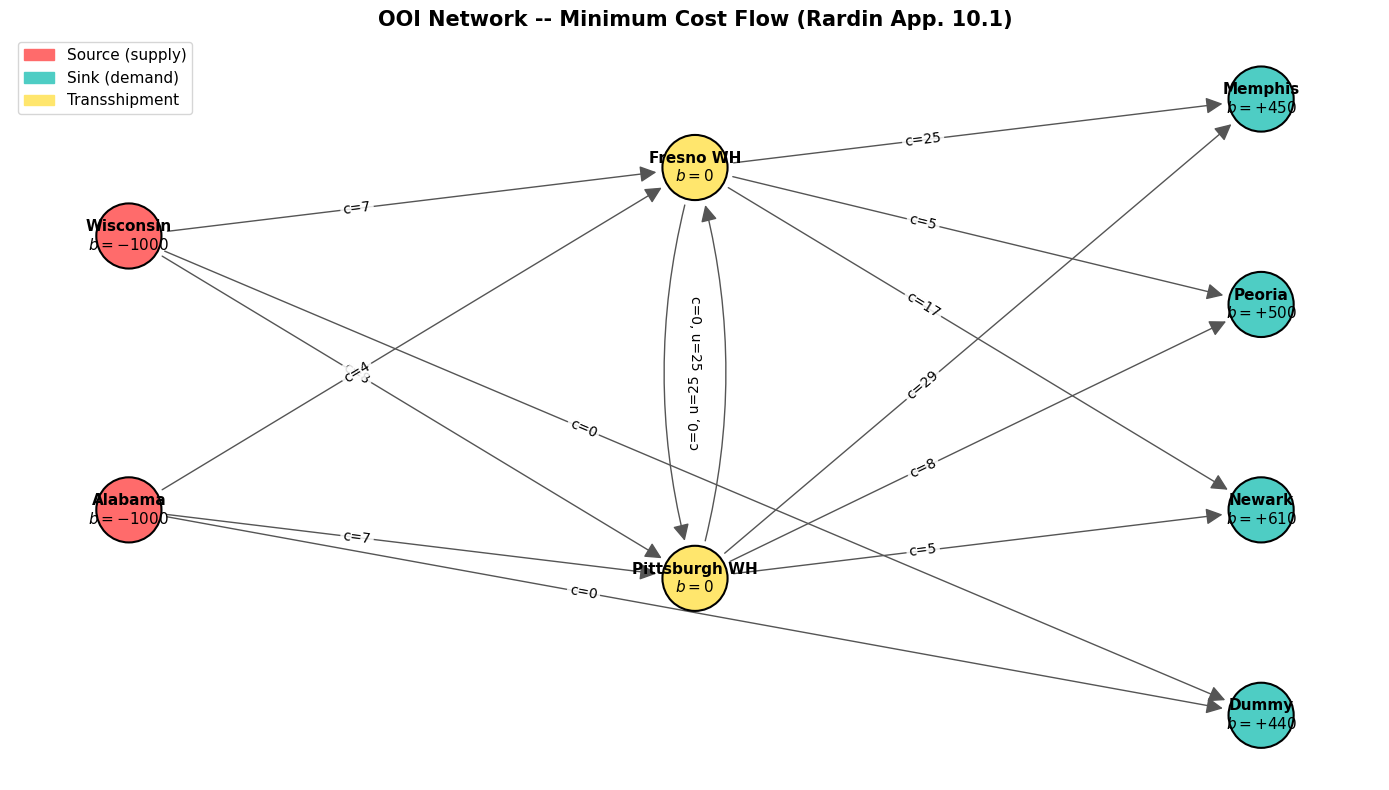

In [10]:
# Define positions for OOI network layout
pos_ooi = {
    1: (0, 2),   2: (0, 0),       # Plants (left)
    3: (2, 2.5), 4: (2, -0.5),    # Warehouses (middle)
    5: (4, 3),   6: (4, 1.5),     # Customers (right)
    7: (4, 0),   8: (4, -1.5),    # Customer + Dummy
}

draw_network(G_ooi, pos_ooi,
             title="OOI Network -- Minimum Cost Flow (Rardin App. 10.1)")


### 2.3 Node-Arc Incidence Matrix

We can extract the node-arc incidence matrix from the NetworkX graph, matching the algebraic representation from the lecture notes.


In [8]:
# Extract the node-arc incidence matrix
incidence = nx.incidence_matrix(G_ooi, oriented=True).toarray()

# Create a readable DataFrame
arc_labels = [f"({i},{j})" for i, j in G_ooi.edges()]
node_labels = [G_ooi.nodes[n].get("label", str(n)) for n in G_ooi.nodes()]

df_incidence = pd.DataFrame(incidence.astype(int),
                            index=node_labels, columns=arc_labels)
print("Node-Arc Incidence Matrix (rows = nodes, columns = arcs)")
print("Each column has exactly one -1 (tail) and one +1 (head)\n")
df_incidence


Node-Arc Incidence Matrix (rows = nodes, columns = arcs)
Each column has exactly one -1 (tail) and one +1 (head)



,"(1,3)","(1,4)","(1,8)","(2,3)","(2,4)","(2,8)","(3,4)","(3,5)","(3,6)","(3,7)","(4,3)","(4,5)","(4,6)","(4,7)"
Wisconsin,-1,-1,-1,0,0,0,0,0,0,0,0,0,0,0
Alabama,0,0,0,-1,-1,-1,0,0,0,0,0,0,0,0
Fresno WH,1,0,0,1,0,0,-1,-1,-1,-1,1,0,0,0
Pittsburgh WH,0,1,0,0,1,0,1,0,0,0,-1,-1,-1,-1
Memphis,0,0,0,0,0,0,0,1,0,0,0,1,0,0
Peoria,0,0,0,0,0,0,0,0,1,0,0,0,1,0
Newark,0,0,0,0,0,0,0,0,0,1,0,0,0,1
Dummy,0,0,1,0,0,1,0,0,0,0,0,0,0,0


### 2.4 Create/Visualize A Network from Node-Arc Incidence Matrix

Given a node-arc incidence matrix, we can reconstruct the network.

Network reconstructed from incidence matrix: 8 nodes, 14 arcs


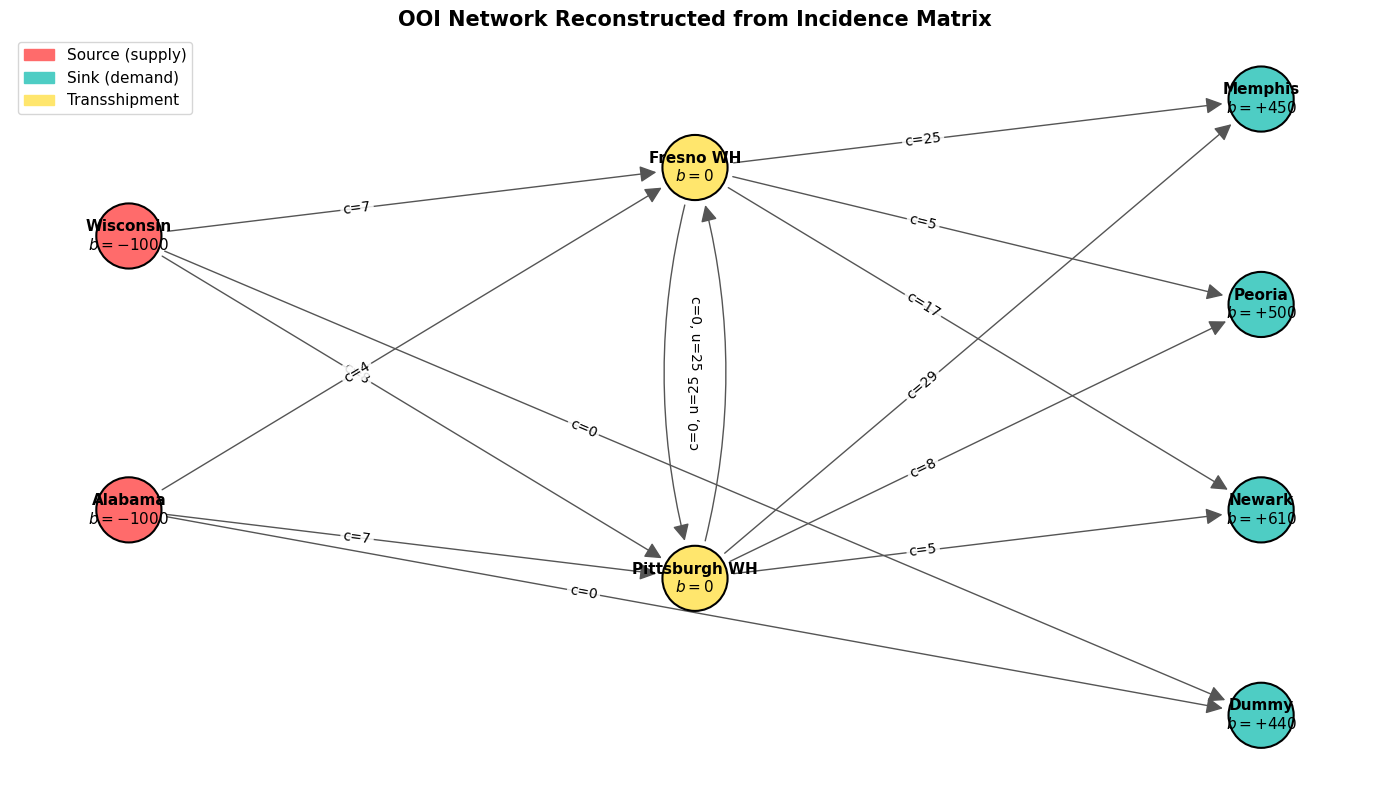

In [11]:
G_from_incidence = nx.DiGraph()

# Create a mapping from node label (from df_incidence index) to node ID (from original 'nodes' dict)
node_label_to_id = {data["label"]: nid for nid, data in nodes.items()}

# Add nodes to the new graph, preserving their original attributes for visualization
for label in df_incidence.index:
    node_id = node_label_to_id[label]
    G_from_incidence.add_node(node_id, **nodes[node_id])

# Add arcs to the new graph, extracting (u,v) from column names and finding original attributes
for arc_str in df_incidence.columns:
    # Parse the arc string, e.g., '(1,3)' to integers (1, 3)
    u, v = map(int, arc_str.strip('()').split(','))

    # Find the corresponding original arc data to get cost and capacity
    arc_attrs = {}
    for orig_u, orig_v, cost, capacity in arcs:
        if (orig_u, orig_v) == (u, v):
            arc_attrs["cost"] = cost
            arc_attrs["capacity"] = capacity
            break
    G_from_incidence.add_edge(u, v, **arc_attrs)

print(f"Network reconstructed from incidence matrix: {G_from_incidence.number_of_nodes()} nodes, {G_from_incidence.number_of_edges()} arcs")

# Visualize the reconstructed network using the predefined draw_network function and positions
draw_network(G_from_incidence, pos_ooi,
             title="OOI Network Reconstructed from Incidence Matrix",
             show_demands=True, show_costs=True, show_capacities=True)

---

## Part 3: Minimum Cost Network Flow -- AMPL Formulation

### 3.1 Generic MCNF Model

We write a **generic** AMPL model for minimum cost network flow that can be reused for any instance by changing only the data.


In [12]:
%%writefile mcnf.mod
# ============================================
# Generic Minimum Cost Network Flow Model
# ============================================

set NODES;
set ARCS within {NODES, NODES};

param b {NODES};             # net demand: < 0 source, > 0 sink, = 0 transship
param cost {ARCS};           # unit cost on each arc
param capacity {ARCS} >= 0;  # arc capacity (use large M for unlimited)

var x {(i,j) in ARCS} >= 0, <= capacity[i,j];

minimize total_cost:
    sum {(i,j) in ARCS} cost[i,j] * x[i,j];

# Flow conservation at every node
subject to flow_balance {k in NODES}:
    sum {(i,k) in ARCS} x[i,k] - sum {(k,j) in ARCS} x[k,j] = b[k];


Writing mcnf.mod


### 3.2 OOI Application Data and Solution


In [13]:
%%writefile ooi.dat
set NODES := 1 2 3 4 5 6 7 8;

set ARCS :=
    (1,3) (1,4) (1,8)
    (2,3) (2,4) (2,8)
    (3,4) (4,3)
    (3,5) (3,6) (3,7)
    (4,5) (4,6) (4,7);

param b :=
    1 -1000   2 -1000
    3  0      4  0
    5  450    6  500
    7  610    8  440;

param cost :=
    1 3  7    1 4  8    1 8  0
    2 3  4    2 4  7    2 8  0
    3 4  0    4 3  0
    3 5  25   3 6  5    3 7  17
    4 5  29   4 6  8    4 7  5;

param capacity :=
    1 3  9999   1 4  9999   1 8  9999
    2 3  9999   2 4  9999   2 8  9999
    3 4  25     4 3  25
    3 5  9999   3 6  9999   3 7  9999
    4 5  9999   4 6  9999   4 7  9999;


Writing ooi.dat


In [14]:
# Solve OOI as MCNF
ooi = AMPL()
ooi.read("mcnf.mod")
ooi.read_data("ooi.dat")
ooi.option["solver"] = "gurobi"
ooi.solve()

print(f"\n--- Optimal Cost: ${ooi.get_value('total_cost'):,.0f} ---\n")
print("Optimal Flows:")
for (i, j), val in ooi.var["x"].get_values().to_dict().items():
    if val > 0.5:
        print(f"  Arc ({int(i)},{int(j)}): {val:,.0f} units")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 25355
4 simplex iterations

--- Optimal Cost: $25,355 ---

Optimal Flows:
  Arc (1,4): 560 units
  Arc (1,8): 440 units
  Arc (2,3): 975 units
  Arc (2,4): 25 units
  Arc (3,4): 25 units
  Arc (3,5): 450 units
  Arc (3,6): 500 units
  Arc (4,7): 610 units


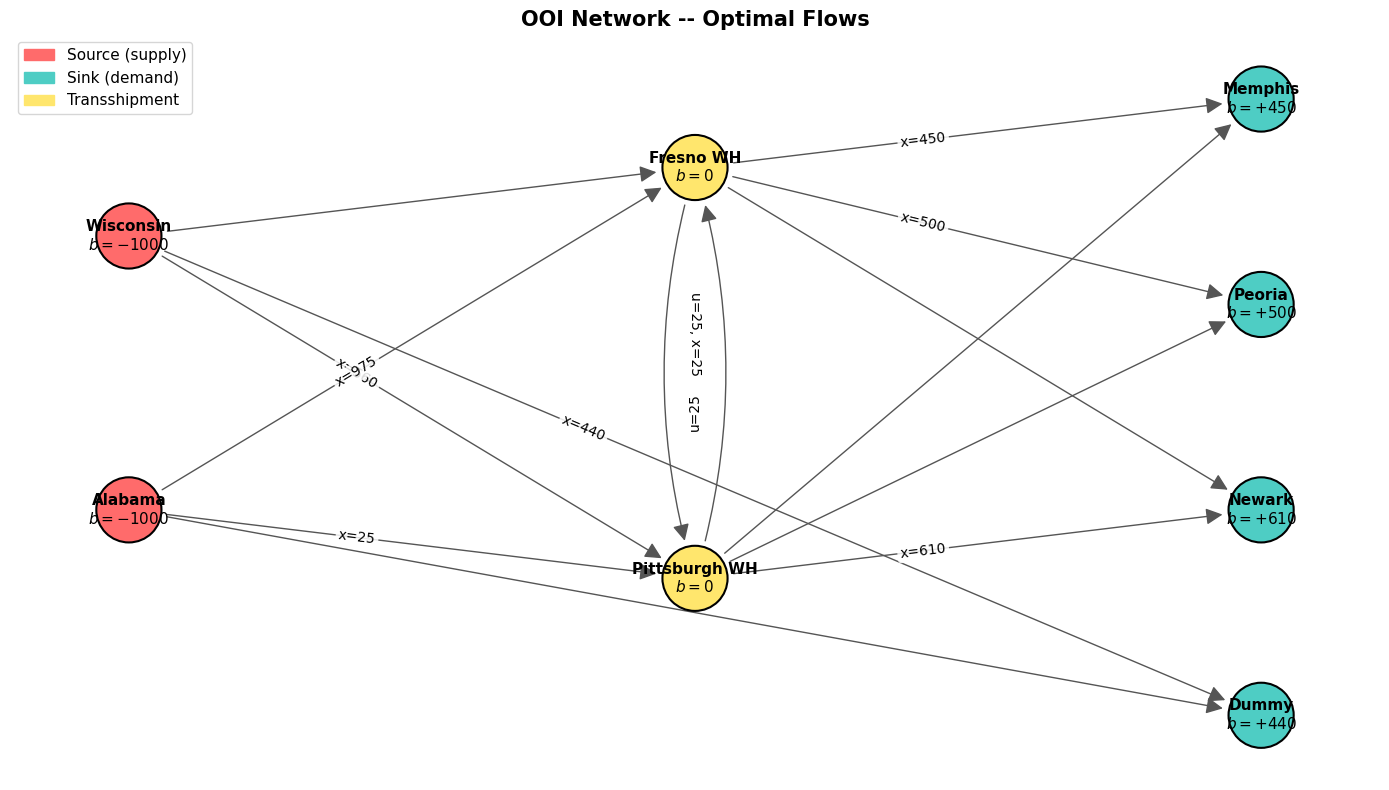

In [15]:
# Visualize optimal flows on the OOI network
flow_dict = {}
for (i, j), val in ooi.var["x"].get_values().to_dict().items():
    if val > 0.5:
        flow_dict[(int(i), int(j))] = val

draw_network(G_ooi, pos_ooi,
             title="OOI Network -- Optimal Flows",
             show_costs=False, flow_dict=flow_dict)


### 3.3 Solving with NetworkX Built-in Algorithm

NetworkX provides `min_cost_flow()` which uses the network simplex algorithm internally. Let's solve the same problem and compare.


In [17]:
# Build a NetworkX-compatible version of the OOI network
# NetworkX min_cost_flow expects 'demand' on nodes, 'weight' on edges
G_ooi_nx = nx.DiGraph()

for n, data in nodes.items():
    G_ooi_nx.add_node(n, demand=data["b"])

for (i, j, c, u) in arcs:
    cap = u if u is not None else 9999
    G_ooi_nx.add_edge(i, j, weight=c, capacity=cap)

# Solve using NetworkX network simplex
flow_cost, flow_result = nx.network_simplex(G_ooi_nx)

print(f"NetworkX Optimal Cost: ${flow_cost:,}")
print("\nOptimal Flows:")
for src, dests in flow_result.items():
    for dst, f in dests.items():
        if f > 0:
            print(f"  Arc ({src},{dst}): {f:,} units")


NetworkX Optimal Cost: $25,355

Optimal Flows:
  Arc (1,4): 560 units
  Arc (1,8): 440 units
  Arc (2,3): 975 units
  Arc (2,4): 25 units
  Arc (3,4): 25 units
  Arc (3,5): 450 units
  Arc (3,6): 500 units
  Arc (4,7): 610 units


**Observation:** Both AMPL/Gurobi and NetworkX's network simplex produce the same optimal cost and flows. The AMPL approach is more flexible for adding side constraints (e.g., minimum flow requirements), while NetworkX is convenient for pure network flow instances.

### 3.4 Smaller Example (Rardin Example 10.1)

A 4-node network with one source, one transshipment node, and two sinks.


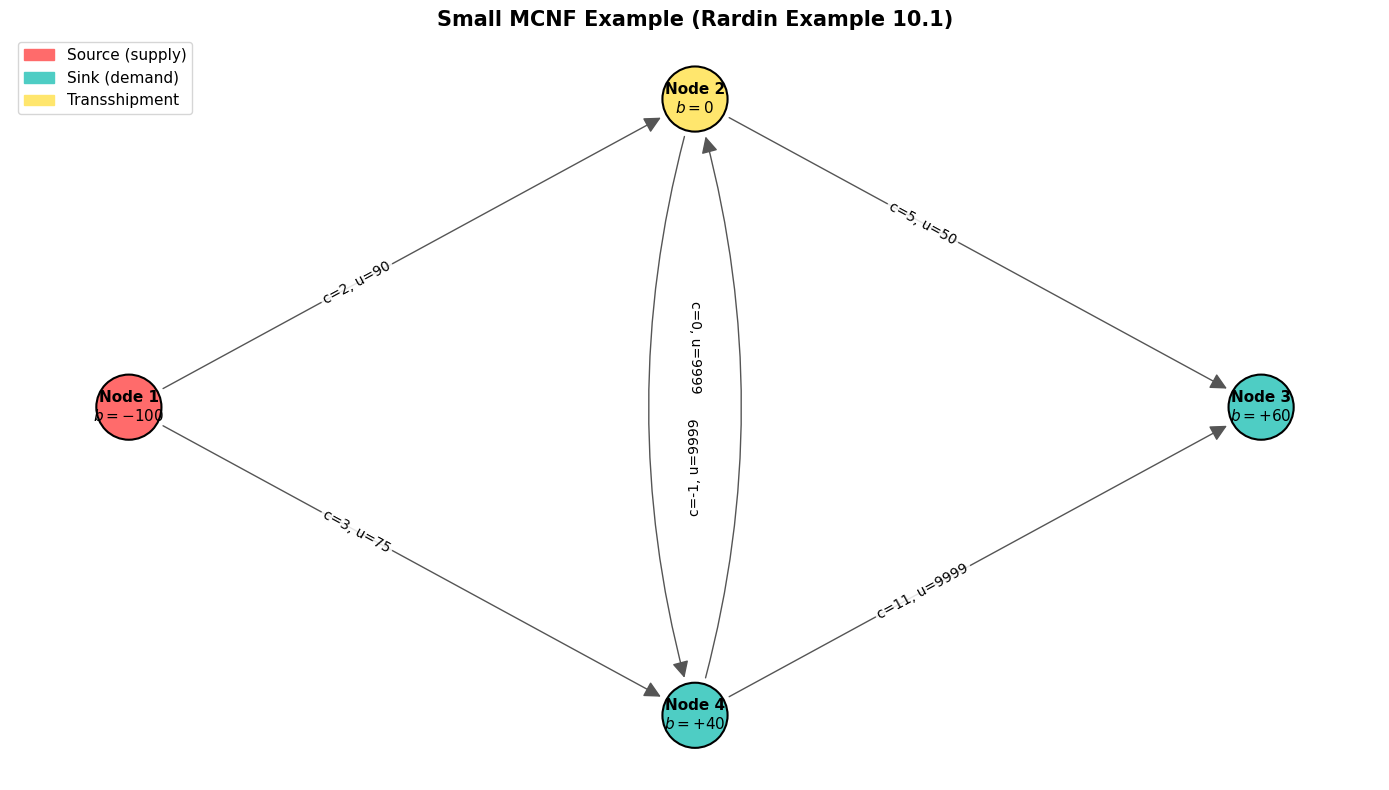

In [18]:
# Build the small 4-node network
G_small = nx.DiGraph()
small_nodes = {
    1: {"label": "Node 1", "b": -100, "type": "source"},
    2: {"label": "Node 2", "b": 0,    "type": "transship"},
    3: {"label": "Node 3", "b": 60,   "type": "sink"},
    4: {"label": "Node 4", "b": 40,   "type": "sink"},
}
for n, d in small_nodes.items():
    G_small.add_node(n, **d)

small_arcs = [(1,2,2,90), (1,4,3,75), (2,3,5,50),
              (2,4,0,9999), (4,2,-1,9999), (4,3,11,9999)]
for i, j, c, u in small_arcs:
    G_small.add_edge(i, j, cost=c, capacity=u)

pos_small = {1: (0, 1), 2: (1, 2), 3: (2, 1), 4: (1, 0)}
draw_network(G_small, pos_small,
             title="Small MCNF Example (Rardin Example 10.1)")


In [ ]:
# Solve with NetworkX
G_small_nx = nx.DiGraph()
for n, d in small_nodes.items():
    G_small_nx.add_node(n, demand=d["b"])
for i, j, c, u in small_arcs:
    G_small_nx.add_edge(i, j, weight=c, capacity=u)

cost_small, flow_small = nx.network_simplex(G_small_nx)
print(f"Optimal Cost: ${cost_small}")
for s, ds in flow_small.items():
    for t, f in ds.items():
        if f > 0:
            print(f"  Arc ({s},{t}): {f} units")


Optimal Cost: $-9389
  Arc (1,2): 50 units
  Arc (1,4): 50 units
  Arc (2,3): 50 units
  Arc (2,4): 9999 units
  Arc (4,2): 9999 units
  Arc (4,3): 10 units


---

## Part 4: Maximum Flow Problem

### 4.1 Building the Network

We use the instance from Rardin Figure 10.25(a). Max flow is MCNF with all costs = 0, all demands = 0, and a return arc (t, s) with cost = -1.


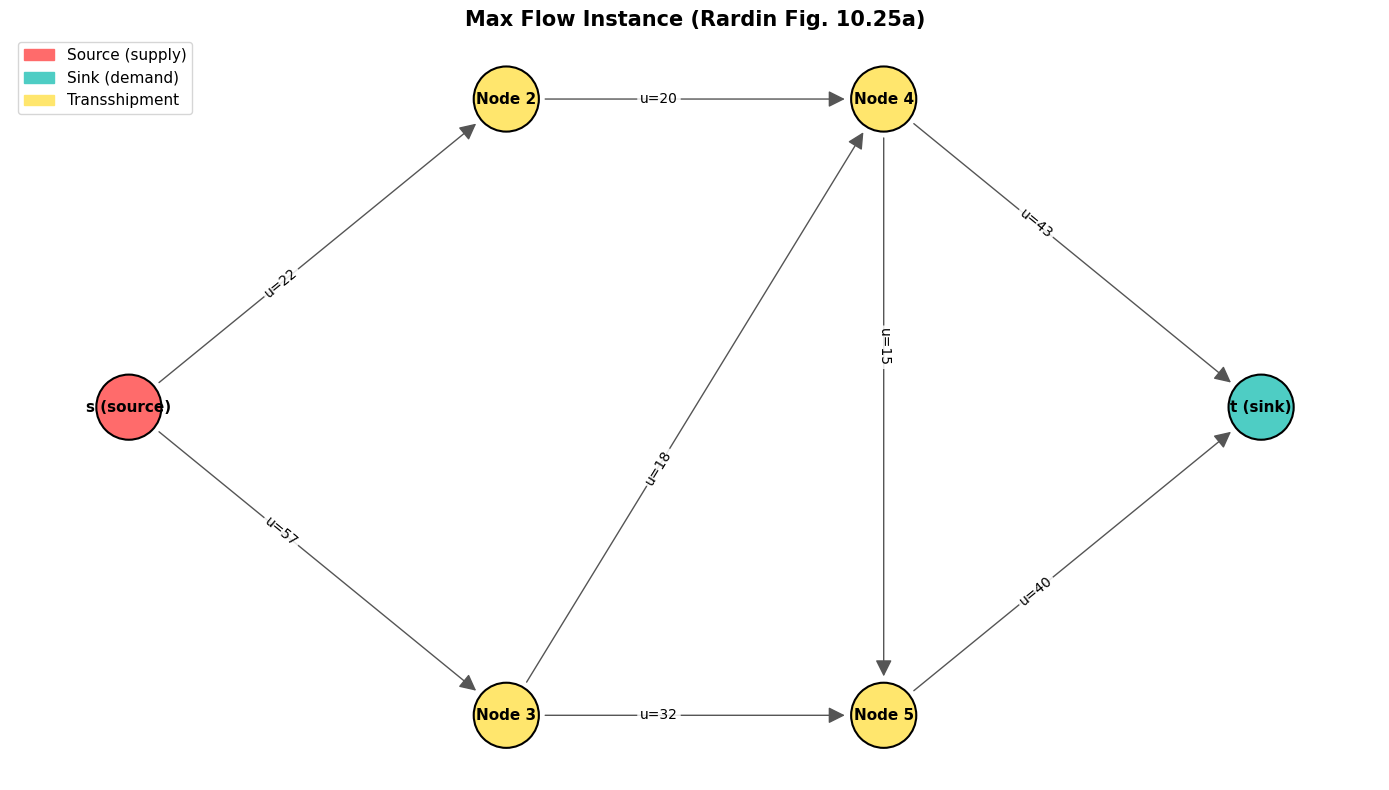

In [19]:
# Build max flow example (Rardin Figure 10.25a)
G_maxflow = nx.DiGraph()
mf_nodes = {
    1: {"label": "s (source)", "b": 0, "type": "source"},
    2: {"label": "Node 2",     "b": 0, "type": "transship"},
    3: {"label": "Node 3",     "b": 0, "type": "transship"},
    4: {"label": "Node 4",     "b": 0, "type": "transship"},
    5: {"label": "Node 5",     "b": 0, "type": "transship"},
    6: {"label": "t (sink)",   "b": 0, "type": "sink"},
}
for n, d in mf_nodes.items():
    G_maxflow.add_node(n, **d)

mf_arcs = [
    (1, 2, 22), (1, 3, 57),
    (2, 4, 20), (3, 4, 18),
    (3, 5, 32), (4, 5, 15),
    (4, 6, 43), (5, 6, 40),
]
for i, j, u in mf_arcs:
    G_maxflow.add_edge(i, j, cost=0, capacity=u)

pos_mf = {1: (0, 1), 2: (1, 2), 3: (1, 0),
           4: (2, 2), 5: (2, 0), 6: (3, 1)}

draw_network(G_maxflow, pos_mf,
             title="Max Flow Instance (Rardin Fig. 10.25a)",
             show_demands=False, show_costs=False)


### 4.2 Solving with AMPL (via MCNF + Return Arc)


In [20]:
%%writefile maxflow.dat
# Max flow as MCNF: add return arc (t=6, s=1) with cost -1

set NODES := 1 2 3 4 5 6;

set ARCS :=
    (1,2) (1,3) (2,4) (3,4) (3,5) (4,5)
    (4,6) (5,6)
    (6,1);

param b := 1 0  2 0  3 0  4 0  5 0  6 0;

param cost :=
    1 2  0    1 3  0    2 4  0    3 4  0
    3 5  0    4 5  0    4 6  0    5 6  0
    6 1  -1;

param capacity :=
    1 2  22   1 3  57   2 4  20   3 4  18
    3 5  32   4 5  15   4 6  43   5 6  40
    6 1  9999;


Writing maxflow.dat


In [21]:
# Solve max flow via MCNF
mf = AMPL()
mf.read("mcnf.mod")
mf.read_data("maxflow.dat")
mf.option["solver"] = "gurobi"
mf.solve()

max_flow_val = mf.var["x"][6, 1].value()
print(f"Maximum Flow (AMPL): {max_flow_val:.0f}")

print("\nOptimal Arc Flows:")
for (i, j), val in mf.var["x"].get_values().to_dict().items():
    if val > 0.5 and not (int(i) == 6 and int(j) == 1):
        print(f"  ({int(i)},{int(j)}): {val:.0f}")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective -70
2 simplex iterations
Maximum Flow (AMPL): 70

Optimal Arc Flows:
  (1,2): 20
  (1,3): 50
  (2,4): 20
  (3,4): 18
  (3,5): 32
  (4,5): 8
  (4,6): 30
  (5,6): 40


### 4.3 Solving with NetworkX


In [22]:
# NetworkX max flow (uses Edmonds-Karp by default)
flow_value, flow_dict_mf = nx.maximum_flow(G_maxflow, 1, 6)
print(f"Maximum Flow (NetworkX): {flow_value}")

print("\nOptimal Arc Flows:")
for s, ds in flow_dict_mf.items():
    for t, f in ds.items():
        if f > 0:
            print(f"  ({s},{t}): {f}")


Maximum Flow (NetworkX): 70

Optimal Arc Flows:
  (1,2): 20
  (1,3): 50
  (2,4): 20
  (3,4): 18
  (3,5): 32
  (4,6): 38
  (5,6): 32


### 4.4 Minimum Cut


In [ ]:
# Find minimum cut
cut_value, (S, T) = nx.minimum_cut(G_maxflow, 1, 6)
print(f"Min Cut Value: {cut_value}")
print(f"S (source side): {sorted(S)}")
print(f"T (sink side):   {sorted(T)}")

# Identify bottleneck arcs (forward arcs across the cut)
print("\nBottleneck arcs (forward arcs across cut):")
for i in S:
    for j in T:
        if G_maxflow.has_edge(i, j):
            cap = G_maxflow[i][j]["capacity"]
            print(f"  ({i},{j}): capacity = {cap}")


Min Cut Value: 70
S (source side): [1, 2, 3]
T (sink side):   [4, 5, 6]

Bottleneck arcs (forward arcs across cut):
  (2,4): capacity = 20
  (3,4): capacity = 18
  (3,5): capacity = 32


---

## Part 5: Shortest Path Problem

### 5.1 Building the Network

Shortest path from node 1 to node 6 (from Exercise 4 in lecture notes). This is MCNF with unit flow: b_s = -1, b_t = +1.


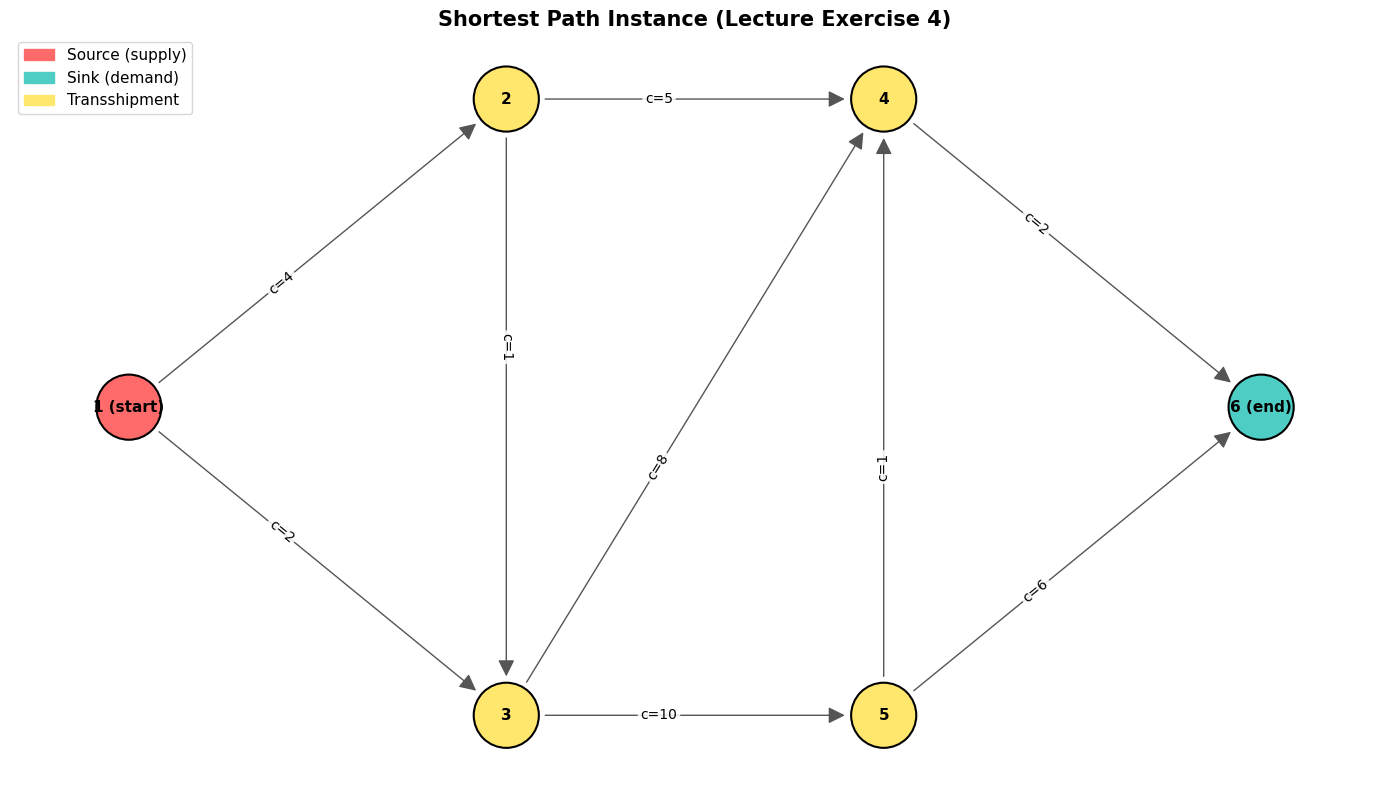

In [23]:
G_sp = nx.DiGraph()
sp_nodes_data = {
    1: {"label": "1 (start)", "b": -1, "type": "source"},
    2: {"label": "2",         "b": 0,  "type": "transship"},
    3: {"label": "3",         "b": 0,  "type": "transship"},
    4: {"label": "4",         "b": 0,  "type": "transship"},
    5: {"label": "5",         "b": 0,  "type": "transship"},
    6: {"label": "6 (end)",   "b": 1,  "type": "sink"},
}
for n, d in sp_nodes_data.items():
    G_sp.add_node(n, **d)

sp_arcs = [(1,2,4), (1,3,2), (2,3,1), (2,4,5),
           (3,4,8), (3,5,10), (4,6,2), (5,4,1), (5,6,6)]
for i, j, c in sp_arcs:
    G_sp.add_edge(i, j, cost=c, capacity=9999)

pos_sp = {1: (0, 1), 2: (1, 2), 3: (1, 0),
           4: (2, 2), 5: (2, 0), 6: (3, 1)}

draw_network(G_sp, pos_sp,
             title="Shortest Path Instance (Lecture Exercise 4)",
             show_demands=False, show_capacities=False)


### 5.2 Solving with AMPL


In [24]:
%%writefile sp.dat
set NODES := 1 2 3 4 5 6;

set ARCS :=
    (1,2) (1,3) (2,3) (2,4) (3,4) (3,5) (4,6) (5,4) (5,6);

param b := 1 -1  2 0  3 0  4 0  5 0  6 1;

param cost :=
    1 2  4   1 3  2   2 3  1   2 4  5
    3 4  8   3 5  10  4 6  2   5 4  1   5 6  6;

param capacity :=
    1 2  9999  1 3  9999  2 3  9999  2 4  9999
    3 4  9999  3 5  9999  4 6  9999  5 4  9999  5 6  9999;


Writing sp.dat


In [25]:
sp_ampl = AMPL()
sp_ampl.read("mcnf.mod")
sp_ampl.read_data("sp.dat")
sp_ampl.option["solver"] = "gurobi"
sp_ampl.solve()

print(f"Shortest Path Cost (AMPL): {sp_ampl.get_value('total_cost'):.0f}")
print("\nPath (arcs with flow = 1):")
for (i, j), val in sp_ampl.var["x"].get_values().to_dict().items():
    if val > 0.5:
        print(f"  ({int(i)},{int(j)}): cost = {G_sp[int(i)][int(j)]['cost']}")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 11
2 simplex iterations
Shortest Path Cost (AMPL): 11

Path (arcs with flow = 1):
  (1,2): cost = 4
  (2,4): cost = 5
  (4,6): cost = 2


### 5.3 Solving with NetworkX (Dijkstra and Bellman-Ford)


In [27]:
# Dijkstra's algorithm (nonnegative costs)
path = nx.dijkstra_path(G_sp, 1, 6, weight="cost")
length = nx.dijkstra_path_length(G_sp, 1, 6, weight="cost")

print(f"Shortest Path (Dijkstra): {' -> '.join(map(str, path))}")
print(f"Total Cost: {length}")

# Bellman-Ford also works (and handles negative costs)
path_bf = nx.bellman_ford_path(G_sp, 1, 6, weight="cost")
length_bf = nx.bellman_ford_path_length(G_sp, 1, 6, weight="cost")

print(f"\nShortest Path (Bellman-Ford): {' -> '.join(map(str, path_bf))}")
print(f"Total Cost: {length_bf}")


Shortest Path (Dijkstra): 1 -> 2 -> 4 -> 6
Total Cost: 11

Shortest Path (Bellman-Ford): 1 -> 2 -> 4 -> 6
Total Cost: 11


---

## Part 6: Transportation Problem

### 6.1 Formulation and Visualization

Two sources, two sinks (Rardin Example 10.22).


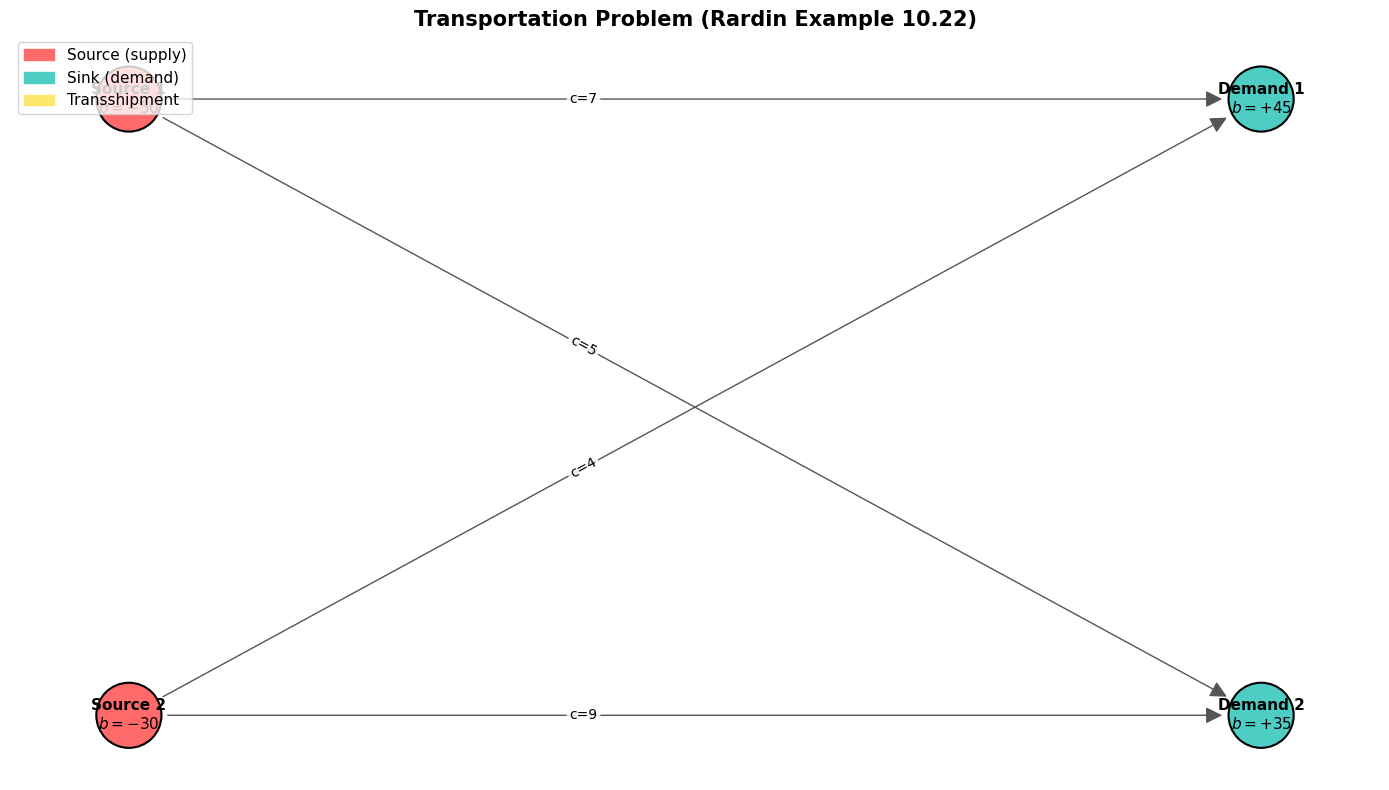

In [28]:
G_trans = nx.DiGraph()
trans_nodes = {
    "S1": {"label": "Source 1", "b": -50, "type": "source"},
    "S2": {"label": "Source 2", "b": -30, "type": "source"},
    "D1": {"label": "Demand 1", "b": 45,  "type": "sink"},
    "D2": {"label": "Demand 2", "b": 35,  "type": "sink"},
}
for n, d in trans_nodes.items():
    G_trans.add_node(n, **d)

trans_arcs = [("S1","D1",7), ("S1","D2",5), ("S2","D1",4), ("S2","D2",9)]
for i, j, c in trans_arcs:
    G_trans.add_edge(i, j, cost=c, capacity=9999)

pos_trans = {"S1": (0, 1), "S2": (0, 0), "D1": (2, 1), "D2": (2, 0)}
draw_network(G_trans, pos_trans,
             title="Transportation Problem (Rardin Example 10.22)",
             show_capacities=False)


### 6.2 Solving with AMPL (Dedicated Transportation Model)


In [ ]:
%%writefile transport.mod
set SOURCES;
set SINKS;

param supply {SOURCES} >= 0;
param demand {SINKS} >= 0;
param cost {SOURCES, SINKS} >= 0;

var x {SOURCES, SINKS} >= 0;

minimize total_cost:
    sum {i in SOURCES, j in SINKS} cost[i,j] * x[i,j];

subject to supply_limit {i in SOURCES}:
    sum {j in SINKS} x[i,j] = supply[i];

subject to demand_fulfill {j in SINKS}:
    sum {i in SOURCES} x[i,j] = demand[j];


Writing transport.mod


In [ ]:
%%writefile transport.dat
set SOURCES := S1 S2;
set SINKS := D1 D2;

param supply := S1 50  S2 30;
param demand := D1 45  D2 35;

param cost:  D1  D2 :=
         S1   7   5
         S2   4   9;


Writing transport.dat


In [ ]:
tp = AMPL()
tp.read("transport.mod")
tp.read_data("transport.dat")
tp.option["solver"] = "gurobi"
tp.solve()

print(f"Optimal Transportation Cost: ${tp.get_value('total_cost'):.0f}\n")
for (i, j), val in tp.var["x"].get_values().to_dict().items():
    if val > 0.5:
        print(f"  {i} -> {j}: {val:.0f} units")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 400
0 simplex iterations
Optimal Transportation Cost: $400

  S1 -> D1: 15 units
  S1 -> D2: 35 units
  S2 -> D1: 30 units


---

## Part 7: Assignment Problem

### 7.1 Dating Service Example (Rardin Example 10.23)

Maximize total compatibility by pairing 3 males with 3 females. Assignment is a special transportation problem with all supplies and demands = 1.


In [30]:
%%writefile assignment.mod
set SETL;
set SETR;

param score {SETL, SETR} default 0;

var x {SETL, SETR} >= 0;   # integrality guaranteed by network structure!

maximize total_score:
    sum {i in SETL, j in SETR} score[i,j] * x[i,j];

subject to assign_left {i in SETL}:
    sum {j in SETR} x[i,j] = 1;

subject to assign_right {j in SETR}:
    sum {i in SETL} x[i,j] = 1;


Overwriting assignment.mod


In [31]:
%%writefile dating.dat
set SETL := M1 M2 M3;
set SETR := F1 F2 F3;

param score:  F1  F2  F3 :=
         M1   90  30  12
         M2   40  80  75
         M3   60  65  80;


Writing dating.dat


In [32]:
ap = AMPL()
ap.read("assignment.mod")
ap.read_data("dating.dat")
ap.option["solver"] = "gurobi"
ap.solve()

print(f"Maximum Compatibility: {ap.get_value('total_score'):.0f}\n")
print("Optimal Pairing:")
for (i, j), val in ap.var["x"].get_values().to_dict().items():
    if val > 0.5:
        print(f"  {i} <-> {j} (score = {ap.param['score'][i, j]:.0f})")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 250
3 simplex iterations
Maximum Compatibility: 250

Optimal Pairing:
  M1 <-> F1 (score = 90)
  M2 <-> F2 (score = 80)
  M3 <-> F3 (score = 80)


Note: Even though we declared `x` as continuous (`>= 0`), the solution is automatically binary (0 or 1). This is the **integrality property** of network flows -- the node-arc incidence matrix is totally unimodular.

### 7.2 Solving with scipy (Hungarian Algorithm)

For linear assignment specifically, scipy provides a very efficient O(n^3) Hungarian algorithm implementation.


In [33]:
from scipy.optimize import linear_sum_assignment

# Cost matrix (negate for maximization)
score_matrix = np.array([
    [90, 30, 12],
    [40, 80, 75],
    [60, 65, 80],
])

# Scipy minimizes, so negate for maximization
row_ind, col_ind = linear_sum_assignment(-score_matrix)

males = ["M1", "M2", "M3"]
females = ["F1", "F2", "F3"]

print("Optimal Pairing (Hungarian Algorithm):")
total = 0
for r, c in zip(row_ind, col_ind):
    print(f"  {males[r]} <-> {females[c]} (score = {score_matrix[r, c]})")
    total += score_matrix[r, c]
print(f"\nTotal Compatibility: {total}")


Optimal Pairing (Hungarian Algorithm):
  M1 <-> F1 (score = 90)
  M2 <-> F2 (score = 80)
  M3 <-> F3 (score = 80)

Total Compatibility: 250


---

## Part 8: Matching Problem

### 8.1 Speaker Pairing (inspired by Rardin Application 11.7)

Unlike assignment, matching pairs objects from a **single** set.
This is an ILP -- the integrality property does **not** apply for general (non-bipartite) matching.


In [34]:
%%writefile matching.mod
set ITEMS ordered;
set PAIRS = {i in ITEMS, j in ITEMS: ord(i) < ord(j)};

param distortion {PAIRS};

var x {PAIRS} binary;   # must be binary -- no TU guarantee!

minimize total_distortion:
    sum {(i,j) in PAIRS} distortion[i,j] * x[i,j];

subject to one_partner {k in ITEMS}:
    sum {(i,k) in PAIRS} x[i,k] + sum {(k,j) in PAIRS} x[k,j] = 1;


Writing matching.mod


In [35]:
%%writefile speakers.dat
set ITEMS := SP1 SP2 SP3 SP4 SP5 SP6;

param distortion :=
    SP1 SP2   3     SP1 SP3   7     SP1 SP4   2
    SP1 SP5   9     SP1 SP6   4
    SP2 SP3   5     SP2 SP4   8     SP2 SP5   1
    SP2 SP6   6
    SP3 SP4   4     SP3 SP5   6     SP3 SP6   3
    SP4 SP5   7     SP4 SP6   5
    SP5 SP6   2;


Writing speakers.dat


In [36]:
match = AMPL()
match.read("matching.mod")
match.read_data("speakers.dat")
match.option["solver"] = "gurobi"
match.solve()

print(f"Minimum Total Distortion: {match.get_value('total_distortion'):.0f}\n")
print("Optimal Pairing:")
for (i, j), val in match.var["x"].get_values().to_dict().items():
    if val > 0.5:
        d = match.param["distortion"][i, j]
        print(f"  {i} <-> {j}  (distortion = {d:.0f})")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 6
4 simplex iterations
1 branching node
Minimum Total Distortion: 6

Optimal Pairing:
  SP1 <-> SP4  (distortion = 2)
  SP2 <-> SP5  (distortion = 1)
  SP3 <-> SP6  (distortion = 3)


### 8.2 Matching Visualization


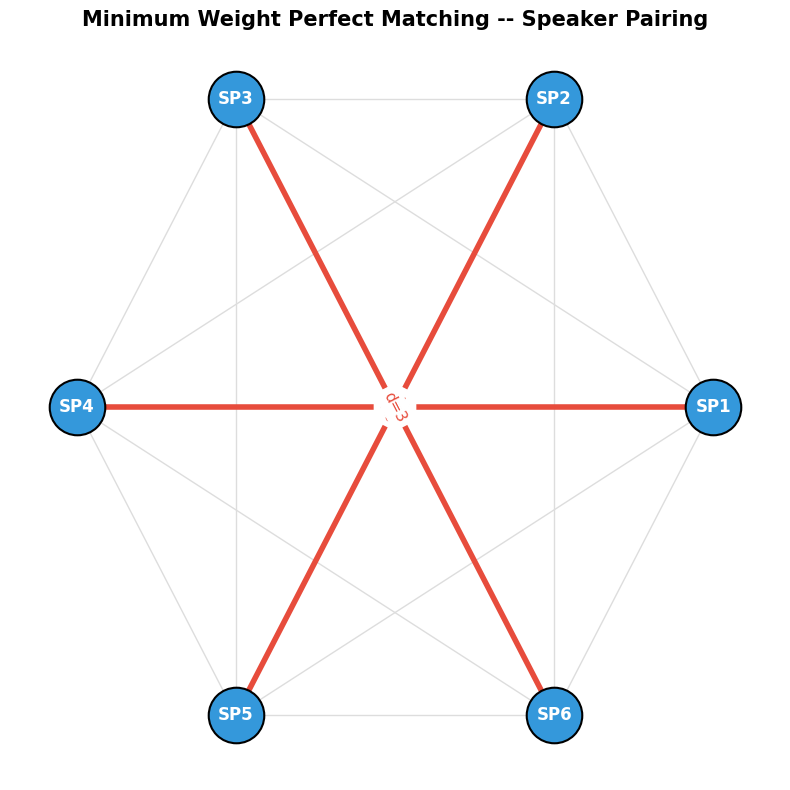

In [37]:
# Visualize matching on an undirected graph
G_match = nx.Graph()
items = ["SP1", "SP2", "SP3", "SP4", "SP5", "SP6"]
G_match.add_nodes_from(items)

# Add all edges with distortion
for (i, j), val in match.param["distortion"].get_values().to_dict().items():
    G_match.add_edge(i, j, distortion=val)

# Identify matched edges
matched_edges = []
for (i, j), val in match.var["x"].get_values().to_dict().items():
    if val > 0.5:
        matched_edges.append((i, j))

pos_match = nx.circular_layout(G_match)
fig, ax = plt.subplots(figsize=(8, 8))

# Draw all edges light gray
nx.draw_networkx_edges(G_match, pos_match, ax=ax,
                       edge_color="#DDDDDD", width=1)
# Draw matched edges bold red
nx.draw_networkx_edges(G_match, pos_match, edgelist=matched_edges, ax=ax,
                       edge_color="#E74C3C", width=4)
# Draw nodes
nx.draw_networkx_nodes(G_match, pos_match, ax=ax,
                       node_color="#3498DB", node_size=1600,
                       edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(G_match, pos_match, ax=ax,
                        font_size=12, font_weight="bold", font_color="white")
# Edge labels for matched
edge_labels = {(i,j): f"d={G_match[i][j]['distortion']}"
               for i, j in matched_edges}
nx.draw_networkx_edge_labels(G_match, pos_match, edge_labels,
                              font_size=11, font_color="#E74C3C", ax=ax)

ax.set_title("Minimum Weight Perfect Matching -- Speaker Pairing",
             fontsize=15, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()


### 8.3 Comparison: NetworkX max_weight_matching

NetworkX also has a built-in matching function (Edmonds' blossom algorithm), though it maximizes weight by default.


In [38]:
# NetworkX matching (maximizes by default, so negate weights for min)
G_match_nx = nx.Graph()
for (i, j), val in match.param["distortion"].get_values().to_dict().items():
    # Negate distortion so max_weight_matching finds min distortion
    G_match_nx.add_edge(i, j, weight=-val)

nx_matching = nx.max_weight_matching(G_match_nx, maxcardinality=True)
print("Optimal Pairing (NetworkX Blossom Algorithm):")
total_d = 0
for i, j in nx_matching:
    d = abs(G_match_nx[i][j]["weight"])
    print(f"  {i} <-> {j}  (distortion = {d:.0f})")
    total_d += d
print(f"\nTotal Distortion: {total_d}")


Optimal Pairing (NetworkX Blossom Algorithm):
  SP2 <-> SP5  (distortion = 1)
  SP1 <-> SP4  (distortion = 2)
  SP6 <-> SP3  (distortion = 3)

Total Distortion: 6


---

## Part 9: Practice Problems

---




### Exercise A: Modified OOI Network

Suppose a **new warehouse** (node 9, in Dallas) is added to the OOI network with the following arcs:

| Arc | Cost | Capacity |
|-----|------|----------|
| (1, 9) | 6 | unlimited |
| (2, 9) | 3 | unlimited |
| (9, 5) | 10 | unlimited |
| (9, 6) | 12 | unlimited |
| (9, 7) | 20 | unlimited |

Node 9 is a transshipment node (b_9 = 0).

**Tasks:**
1. Add node 9 and its arcs to the OOI data file
2. Solve the updated MCNF and compare the new optimal cost to the original
3. Visualize the new network with optimal flows
4. Which customers benefit from the new warehouse?

---


### Exercise B: Evacuation Max Flow

A campus building has the following emergency exit network:

| Arc | Capacity (persons/min) |
|-----|----------------------|
| (s, A) | 200 |
| (s, B) | 150 |
| (A, C) | 120 |
| (A, D) | 100 |
| (B, C) | 80 |
| (B, D) | 150 |
| (C, t) | 180 |
| (D, t) | 200 |

**Tasks:**
1. Build the network in NetworkX and visualize it
2. Find the maximum evacuation rate using both AMPL and `nx.maximum_flow`
3. Identify the minimum cut -- which corridors are bottlenecks?
4. If you can widen one corridor by 50 persons/min, which one gives the largest improvement? Verify computationally.

---


### Exercise C: Warehouse-to-Store Transportation

A retail chain has 3 warehouses and 4 stores with the following data:

| | Store 1 | Store 2 | Store 3 | Store 4 |
|---|---|---|---|---|
| Warehouse A (supply: 300) | 8 | 6 | 10 | 9 |
| Warehouse B (supply: 250) | 9 | 12 | 7 | 5 |
| Warehouse C (supply: 200) | 14 | 9 | 16 | 4 |

Store demands: 150, 180, 120, 200.

**Tasks:**
1. Check if supply-demand is balanced. If not, add a dummy node.
2. Formulate and solve using the `transport.mod` model (extend for 3 sources, 4 sinks)
3. Which warehouse ships to the most stores?
4. If Warehouse B's supply drops to 150, what happens to the optimal cost?

---


### Exercise D: Team Project Matching

Eight students need to be formed into 4 pairs for a term project. Their pairwise compatibility scores are:

|    | S2 | S3 | S4 | S5 | S6 | S7 | S8 |
|----|----|----|----|----|----|----|-----|
| S1 | 8  | 5  | 9  | 3  | 7  | 4  | 6   |
| S2 |    | 6  | 4  | 8  | 2  | 7  | 3   |
| S3 |    |    | 7  | 5  | 9  | 1  | 8   |
| S4 |    |    |    | 6  | 3  | 5  | 2   |
| S5 |    |    |    |    | 4  | 8  | 7   |
| S6 |    |    |    |    |    | 6  | 5   |
| S7 |    |    |    |    |    |    | 9   |

**Tasks:**
1. Formulate as a max weight perfect matching problem using `matching.mod`
2. Solve and report the optimal teams
3. Students S1 and S4 request NOT to be paired. Add this constraint and re-solve.
4. Visualize both solutions (before and after the constraint) on circular graphs.

---


### Exercise E: Multi-City Shortest Path

A delivery company operates between 8 cities. Travel times (hours) are:

| From | To | Time | From | To | Time |
|------|-----|------|------|-----|------|
| A | B | 4 | D | E | 1 |
| A | D | 6 | E | F | 2 |
| B | C | 3 | E | G | 3 |
| B | D | 2 | E | H | 9 |
| B | E | 7 | F | H | 6 |
| C | E | 4 | G | H | 2 |
| C | F | 5 | | | |

**Tasks:**
1. Build the network and visualize it
2. Find the shortest path from A to H using Dijkstra (NetworkX)
3. Solve the same problem as an MCNF with AMPL
4. Find the shortest paths from A to **all** other cities using `nx.single_source_dijkstra`
5. If the road from D to E is closed, what is the new shortest path from A to H?

---


## Summary

In this lab, we covered computational methods for the entire network flow family:

| Problem | AMPL Approach | NetworkX / SciPy Function |
|---------|--------------|---------------------------|
| Min Cost Flow | Generic `mcnf.mod` | `nx.network_simplex()` |
| Max Flow | MCNF + return arc | `nx.maximum_flow()`, `nx.minimum_cut()` |
| Shortest Path | MCNF with unit flow | `nx.dijkstra_path()`, `nx.bellman_ford_path()` |
| Transportation | Dedicated `transport.mod` | `nx.network_simplex()` (via MCNF) |
| Assignment | LP relaxation (TU gives integrality) | `scipy.optimize.linear_sum_assignment()` |
| Matching | ILP (`binary` variables required) | `nx.max_weight_matching()` |

**Key insight:** The AMPL/MCNF approach is unified and extensible -- you can add side constraints to any network model. The NetworkX functions are faster for standard instances but less flexible for variants.
